In [20]:
import os
os.environ["OPENCV_ENABLE_NONFREE_ALGORITHMS"] = "1"  # Must be before import

import cv2
import numpy as np
import matplotlib.pyplot as plt


In [29]:
import cv2
print(cv2.__version__)           # Should NOT be 4.13.0
print(cv2.xfeatures2d.SURF_create)  # Should not raise error

4.10.0
<built-in function SURF_create>


## SIFT (Scale-Invariant Feature Transform)

In [22]:
image1 = cv2.imread('pexels-alexgtacar-745150-1592384.jpg')
image2 = cv2.imread('1238127.jpg')
print(image1.shape)
print(image2.shape)
image1 = cv2.resize(image1, (400, 400))
image2 = cv2.resize(image2, (400, 400))
 
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)
 

(2160, 2160, 3)
(3184, 5404, 3)


### Detect Key Points

In [23]:
sift = cv2.SIFT_create()
keypoint1 = sift.detect(gray1, None)
keypoint2 = sift.detect(gray2, None)
print(f'Keypoints in image 1: {len(keypoint1)}')
print(f'Keypoints in image 2: {len(keypoint2)}')
 

Keypoints in image 1: 247
Keypoints in image 2: 383


### Draw Keypoints

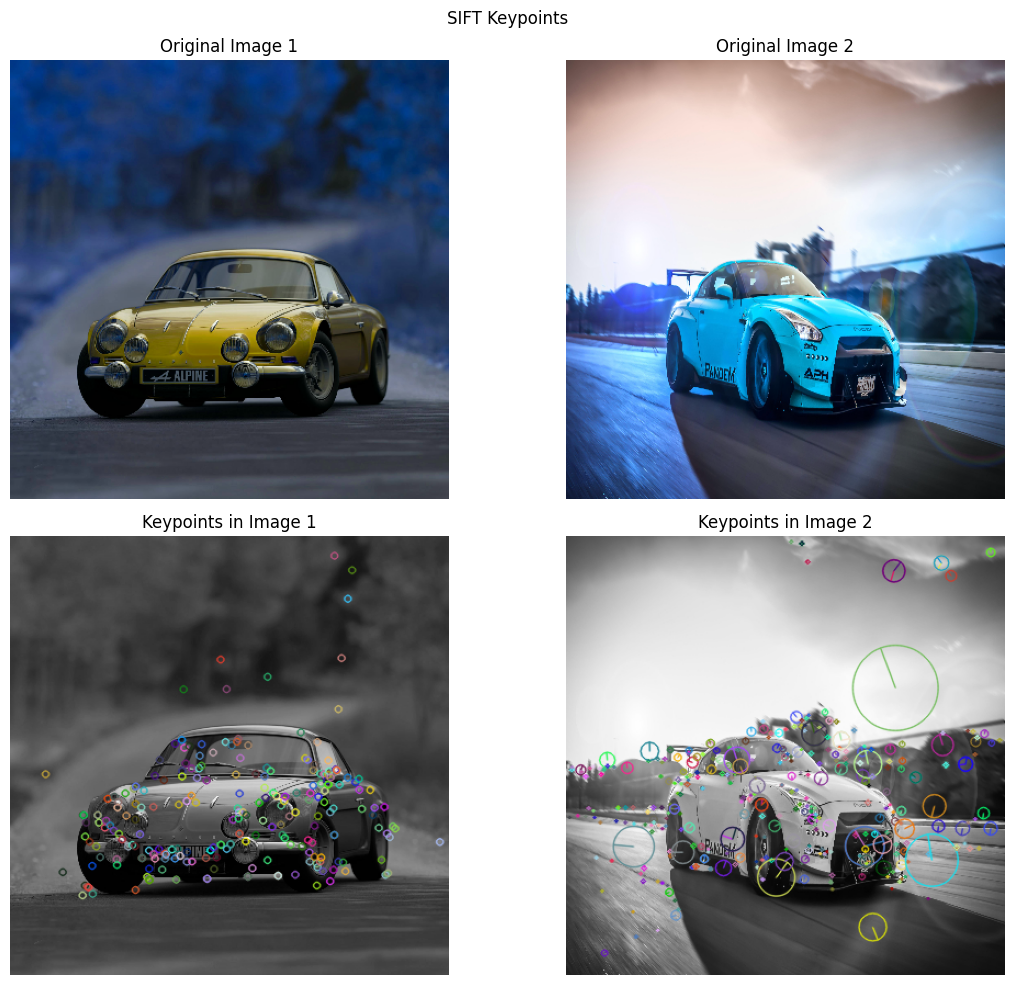

In [24]:
imagekp1 = cv2.drawKeypoints(gray1, keypoint1, gray1)
imagekp2 = cv2.drawKeypoints(gray2, keypoint2, gray2,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1); plt.imshow(image1);   plt.title('Original Image 1'); plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(image2);   plt.title('Original Image 2'); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(imagekp1); plt.title('Keypoints in Image 1'); plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(imagekp2); plt.title('Keypoints in Image 2'); plt.axis('off')
plt.suptitle('SIFT Keypoints')
plt.tight_layout()
plt.show()

### Compile Descriptors & match features

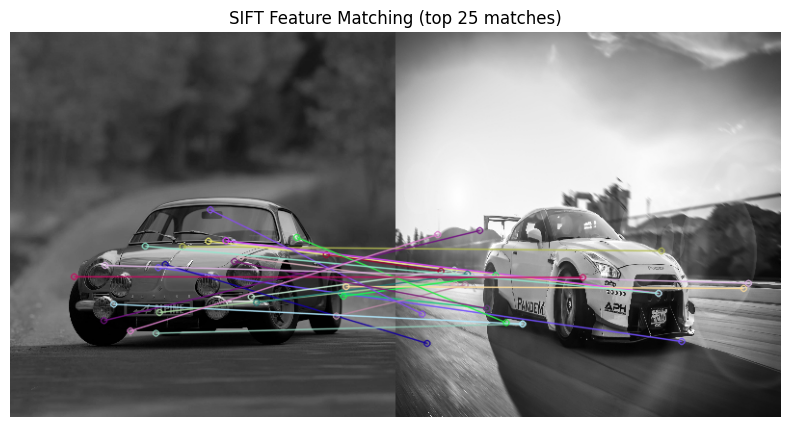

In [25]:
kp1, des1 = sift.compute(gray1, keypoint1)        # compute descriptors for pre-detected kps
kp2, des2 = sift.detectAndCompute(gray2, None)    # detect + compute in one step
 
bf      = cv2.BFMatcher(cv2.NORM_L1)              # Brute-Force matcher with L1 norm
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)  # sort by distance (best match first)
 
img3 = cv2.drawMatches(gray1, kp1, gray2, kp2, matches[:25], gray2,
                        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(14, 5))
plt.imshow(img3)
plt.title('SIFT Feature Matching (top 25 matches)')
plt.axis('off')
plt.show()

### SURF (Speeded-Up Robust Features)

In [27]:
image_1 = cv2.imread('pexels-alexgtacar-745150-1592384.jpg')
image_2 = cv2.imread('1238127.jpg')
gray_1  = cv2.cvtColor(image_1, cv2.COLOR_BGR2GRAY)
gray_2  = cv2.cvtColor(image_2, cv2.COLOR_BGR2GRAY)
 
try:
    surf = cv2.xfeatures2d.SURF_create(400)  # Hessian threshold (lower = more keypoints)
    surf.upright  = True   # disable rotation invariance (faster)
    surf.extended = True   # use 128-dim descriptor instead of 64-dim
 
    keypoint_1 = surf.detect(gray_1, None)
    keypoint_2 = surf.detect(gray_2, None)
    print(f'SURF Keypoints in image 1: {len(keypoint_1)}')
    print(f'SURF Keypoints in image 2: {len(keypoint_2)}')
 
    image_kp1 = cv2.drawKeypoints(gray_1, keypoint_1, gray_1)
    image_kp2 = cv2.drawKeypoints(gray_2, keypoint_2, gray_2,
                                   flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
 
    kp_1, des_1 = surf.compute(gray_1, keypoint_1)
    kp_2, des_2 = surf.detectAndCompute(gray_2, None)
 
    bf_surf   = cv2.BFMatcher(cv2.NORM_L1)
    matches_s = bf_surf.match(des_1, des_2)
    matches_s = sorted(matches_s, key=lambda x: x.distance)
 
    img_3 = cv2.drawMatches(gray_1, kp_1, gray_2, kp_2, matches_s[:50], gray_2,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(14, 5))
    plt.imshow(img_3)
    plt.title('SURF Feature Matching (top 50 matches)')
    plt.axis('off')
    plt.show()
 
except AttributeError:
    print('SURF is not available in this build of OpenCV '
          '(requires opencv-contrib-python with non-free modules enabled).')
 














error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv_contrib\modules\xfeatures2d\src\surf.cpp:1028: error: (-213:The function/feature is not implemented) This algorithm is patented and is excluded in this configuration; Set OPENCV_ENABLE_NONFREE CMake option and rebuild the library in function 'cv::xfeatures2d::SURF::create'
